In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools #FOr confusion matrix
import warnings
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv('/content/malicious_phish.csv')
df.head()

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [15]:
!pip install tld statsmodels xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 20.9 MB/s eta 0:00:00


In [ ]:
print(df.columns.tolist())

['url', 'type']


In [ ]:
# ============================================================
# SECUREQR: DATASET / FEATURE DIAGNOSTIC
# Run this BEFORE the SecureQR fixes code
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("DATAFRAME BASIC INFO")
print("=" * 80)

print("df type:", type(df))
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\n" + "=" * 80)
print("ALL COLUMN NAMES")
print("=" * 80)

for i, col in enumerate(df.columns):
    print(f"{i:3d}: {repr(col)}")


print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)

print(df.dtypes)


print("\n" + "=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)

display(df.head())


print("\n" + "=" * 80)
print("COLUMN NAMES NORMALIZED")
print("=" * 80)

# Show columns after removing leading/trailing spaces
for col in df.columns:
    cleaned = str(col).strip()
    if cleaned != col:
        print(f"Original: {repr(col)}  -->  Cleaned: {repr(cleaned)}")


print("\n" + "=" * 80)
print("POSSIBLE URL / LABEL COLUMNS")
print("=" * 80)

for col in df.columns:
    c = str(col).lower().strip()

    if any(x in c for x in [
        "url", "type", "label", "class", "target", "category", "domain"
    ]):
        print(repr(col))


print("\n" + "=" * 80)
print("POSSIBLE FEATURE COLUMNS")
print("=" * 80)

feature_keywords = [
    "ip",
    "abnormal",
    "google",
    "count",
    "short",
    "https",
    "http",
    "length",
    "sus",
    "digit",
    "letter",
    "tld",
    "embed",
    "dir",
    "url"
]

for col in df.columns:
    c = str(col).lower().strip()

    if any(k in c for k in feature_keywords):
        print(repr(col))


print("\n" + "=" * 80)
print("MISSING FEATURES FROM YOUR SCRIPT")
print("=" * 80)

EXPECTED_FEATURES = [
    'use_of_ip',
    'abnormal_url',
    'google_index',
    'count. ',
    'count-www',
    'count@',
    'count_dir',
    'count_embed_domain',
    'short_url',
    'count-https',
    'count-http',
    'count%',
    'count?',
    'count=',
    'url_length',
    'hostname_length',
    'sus_url',
    'count_digits',
    'count-letters',
    'fd_length',
    'tld_length'
]

existing = set(df.columns)

for feature in EXPECTED_FEATURES:
    if feature in existing:
        print("FOUND :", repr(feature))
    else:
        print("MISSING:", repr(feature))


print("\n" + "=" * 80)
print("POSSIBLE TYPE / LABEL VALUES")
print("=" * 80)

for col in df.columns:
    c = str(col).lower().strip()

    if c in ["type", "type_code", "label", "class", "target", "category"]:
        print(f"\nColumn: {repr(col)}")
        print(df[col].value_counts(dropna=False))


print("\n" + "=" * 80)
print("NULL COUNTS")
print("=" * 80)

nulls = df.isna().sum()
print(nulls[nulls > 0].sort_values(ascending=False).head(30))


print("\n" + "=" * 80)
print("DIAGNOSTIC COMPLETE")
print("=" * 80)

DATAFRAME BASIC INFO
df type: <class 'pandas.core.frame.DataFrame'>
Rows: 651191
Columns: 2

ALL COLUMN NAMES
  0: 'url'
  1: 'type'

DATA TYPES
url     object
type    object
dtype: object

FIRST 5 ROWS


,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement



COLUMN NAMES NORMALIZED

POSSIBLE URL / LABEL COLUMNS
'url'
'type'

POSSIBLE FEATURE COLUMNS
'url'

MISSING FEATURES FROM YOUR SCRIPT
MISSING: 'use_of_ip'
MISSING: 'abnormal_url'
MISSING: 'google_index'
MISSING: 'count. '
MISSING: 'count-www'
MISSING: 'count@'
MISSING: 'count_dir'
MISSING: 'count_embed_domain'
MISSING: 'short_url'
MISSING: 'count-https'
MISSING: 'count-http'
MISSING: 'count%'
MISSING: 'count?'
MISSING: 'count='
MISSING: 'url_length'
MISSING: 'hostname_length'
MISSING: 'sus_url'
MISSING: 'count_digits'
MISSING: 'count-letters'
MISSING: 'fd_length'
MISSING: 'tld_length'

POSSIBLE TYPE / LABEL VALUES

Column: 'type'
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

NULL COUNTS
Series([], dtype: int64)

DIAGNOSTIC COMPLETE


In [ ]:
# ============================================================
# CHECK LABEL + URL COLUMNS
# ============================================================

print("Columns containing URL:")
for c in df.columns:
    if "url" in str(c).lower():
        print(repr(c))

print("\nColumns containing TYPE/LABEL/CLASS:")
for c in df.columns:
    if any(x in str(c).lower() for x in ["type", "label", "class", "target", "category"]):
        print(repr(c))

print("\nUnique values of likely label columns:")

for c in df.columns:
    name = str(c).lower().strip()

    if any(x in name for x in ["type", "label", "class", "target", "category"]):
        print("\nCOLUMN:", repr(c))
        print(df[c].value_counts(dropna=False))

Columns containing URL:
'url'

Columns containing TYPE/LABEL/CLASS:
'type'

Unique values of likely label columns:

COLUMN: 'type'
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64


In [ ]:
# ============================================================
# SECUREQR: GENERATE THE 21 URL FEATURES
# Run after your raw df has url + type
# ============================================================

import re
import numpy as np
import pandas as pd
from urllib.parse import urlparse
from tld import get_fld

print("Starting feature extraction...")
print("Rows:", len(df))


# ------------------------------------------------------------
# 1. Helper functions
# ------------------------------------------------------------

def safe_url(url):
    """
    Make URL parseable even when scheme is missing.
    """
    if pd.isna(url):
        return ""

    url = str(url).strip()

    if not url:
        return ""

    if not re.match(r"^[a-zA-Z][a-zA-Z0-9+.-]*://", url):
        url = "http://" + url

    return url


def get_parsed(url):
    try:
        return urlparse(safe_url(url))
    except Exception:
        return None


def get_hostname(url):
    try:
        p = get_parsed(url)
        return p.hostname or ""
    except Exception:
        return ""


def get_path(url):
    try:
        p = get_parsed(url)
        return p.path or ""
    except Exception:
        return ""


def get_domain(url):
    try:
        domain = get_fld(
            str(url),
            fix_protocol=True,
            fail_silently=True
        )

        if domain:
            return domain

        p = get_parsed(url)
        return p.netloc or ""

    except Exception:
        return ""


# ------------------------------------------------------------
# 2. Feature extraction
# ------------------------------------------------------------

def extract_features(url):

    original = "" if pd.isna(url) else str(url).strip()

    parsed = get_parsed(original)

    if parsed is None:
        hostname = ""
        path = ""
        netloc = ""
        query = ""
    else:
        hostname = parsed.hostname or ""
        path = parsed.path or ""
        netloc = parsed.netloc or ""
        query = parsed.query or ""

    full_url = original.lower()

    # Full URL without scheme
    url_no_scheme = re.sub(
        r"^[a-zA-Z][a-zA-Z0-9+.-]*://",
        "",
        full_url
    )

    # --------------------------------------------------------
    # Individual features
    # --------------------------------------------------------

    # 1. use_of_ip
    try:
        ip_match = re.match(
            r"^(?:\d{1,3}\.){3}\d{1,3}$",
            hostname
        )
        use_of_ip = int(ip_match is not None)
    except Exception:
        use_of_ip = 0

    # 2. abnormal_url
    abnormal_url = int(
        ("@" in full_url) or
        (".." in hostname) or
        (len(hostname) == 0)
    )

    # 3. google_index
    # Preserve as a URL-level feature.
    # Google indexing itself is not queried here.
    # Existing SecureQR feature convention commonly uses
    # suspicious URL structure as proxy.
    google_index = int(
        hostname.startswith("www.") and
        len(hostname) > 4
    )

    # 4. count.
    count_dot = full_url.count(".")

    # 5. count-www
    count_www = full_url.count("www")

    # 6. count@
    count_at = full_url.count("@")

    # 7. count_dir
    count_dir = path.count("/")

    # 8. count_embed_domain
    # Count external/embedded domain separators.
    count_embed_domain = max(
        0,
        len(re.findall(r"https?://", full_url)) - 1
    )

    # 9. short_url
    shortening_services = [
        "bit.ly",
        "goo.gl",
        "tinyurl.com",
        "ow.ly",
        "t.co",
        "is.gd",
        "buff.ly",
        "adf.ly",
        "bit.do",
        "tiny.cc",
        "lnkd.in",
        "cutt.ly",
        "shorturl.at"
    ]

    short_url = int(
        any(service in full_url for service in shortening_services)
    )

    # 10. count-https
    count_https = full_url.count("https")

    # 11. count-http
    count_http = full_url.count("http")

    # 12. count%
    count_percent = full_url.count("%")

    # 13. count?
    count_question = full_url.count("?")

    # 14. count=
    count_equal = full_url.count("=")

    # 15. url_length
    url_length = len(original)

    # 16. hostname_length
    hostname_length = len(hostname)

    # 17. sus_url
    suspicious_words = [
        "login",
        "signin",
        "verify",
        "verification",
        "account",
        "secure",
        "update",
        "confirm",
        "password",
        "bank",
        "paypal",
        "credential",
        "wallet"
    ]

    sus_url = int(
        any(word in full_url for word in suspicious_words)
    )

    # 18. count_digits
    count_digits = sum(c.isdigit() for c in original)

    # 19. count-letters
    count_letters = sum(c.isalpha() for c in original)

    # 20. fd_length
    fd_length = len(path.strip("/").split("/")[0]) if path.strip("/") else 0

    # 21. tld_length
    try:
        registrable = get_fld(
            original,
            fix_protocol=True,
            fail_silently=True
        )

        if registrable and "." in registrable:
            tld = registrable.split(".")[-1]
            tld_length = len(tld)
        else:
            tld_length = 0

    except Exception:
        tld_length = 0

    return [
        use_of_ip,
        abnormal_url,
        google_index,
        count_dot,
        count_www,
        count_at,
        count_dir,
        count_embed_domain,
        short_url,
        count_https,
        count_http,
        count_percent,
        count_question,
        count_equal,
        url_length,
        hostname_length,
        sus_url,
        count_digits,
        count_letters,
        fd_length,
        tld_length
    ]


# ------------------------------------------------------------
# 3. Feature names
# ------------------------------------------------------------

FEATURES = [
    'use_of_ip',
    'abnormal_url',
    'google_index',
    'count. ',
    'count-www',
    'count@',
    'count_dir',
    'count_embed_domain',
    'short_url',
    'count-https',
    'count-http',
    'count%',
    'count?',
    'count=',
    'url_length',
    'hostname_length',
    'sus_url',
    'count_digits',
    'count-letters',
    'fd_length',
    'tld_length'
]


# ------------------------------------------------------------
# 4. Generate features
# ------------------------------------------------------------

feature_data = df['url'].apply(extract_features)

feature_df = pd.DataFrame(
    feature_data.tolist(),
    columns=FEATURES,
    index=df.index
)


# ------------------------------------------------------------
# 5. Add features to df
# ------------------------------------------------------------

for col in FEATURES:
    df[col] = feature_df[col]


# ------------------------------------------------------------
# 6. Encode labels
# ------------------------------------------------------------

label_map = {
    'benign': 0,
    'defacement': 1,
    'malware': 2,
    'phishing': 3
}

df['type_code'] = df['type'].map(label_map)


# ------------------------------------------------------------
# 7. Validation
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("FEATURE EXTRACTION COMPLETE")
print("=" * 80)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\n21 FEATURES:")
for i, col in enumerate(FEATURES, 1):
    print(f"{i:2d}. {col}")

print("\nMissing feature values:")
print(df[FEATURES].isna().sum().sum())

print("\nLabel mapping:")
print(df[['type', 'type_code']].drop_duplicates().sort_values('type_code'))

print("\nClass distribution:")
print(df['type'].value_counts())

print("\nFeature dataframe:")
display(df[['url', 'type', 'type_code'] + FEATURES].head())

print("\nFeature dtypes:")
print(df[FEATURES].dtypes)

print("\n" + "=" * 80)
print("READY FOR MODEL EVALUATION")
print("=" * 80)

Starting feature extraction...
Rows: 651191

FEATURE EXTRACTION COMPLETE
Rows: 651191
Columns: 24

21 FEATURES:
 1. use_of_ip
 2. abnormal_url
 3. google_index
 4. count. 
 5. count-www
 6. count@
 7. count_dir
 8. count_embed_domain
 9. short_url
10. count-https
11. count-http
12. count%
13. count?
14. count=
15. url_length
16. hostname_length
17. sus_url
18. count_digits
19. count-letters
20. fd_length
21. tld_length

Missing feature values:
0

Label mapping:
          type  type_code
1       benign          0
3   defacement          1
38     malware          2
0     phishing          3

Class distribution:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Feature dataframe:


,url,type,type_code,use_of_ip,abnormal_url,google_index,count.,count-www,count@,count_dir,...,count%,count?,count=,url_length,hostname_length,sus_url,count_digits,count-letters,fd_length,tld_length
0,br-icloud.com.br,phishing,3,0,0,0,2,0,0,0,...,0,0,0,16,16,0,0,13,0,2
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,0,0,2,0,0,2,...,0,0,0,35,11,0,1,29,5,3
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,0,0,2,0,0,3,...,0,0,0,31,14,0,1,25,7,3
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,0,0,1,3,1,0,1,...,0,1,4,88,21,0,7,63,9,2
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,0,0,0,2,0,0,1,...,0,1,3,235,23,0,22,199,9,3



Feature dtypes:
use_of_ip             int64
abnormal_url          int64
google_index          int64
count.                int64
count-www             int64
count@                int64
count_dir             int64
count_embed_domain    int64
short_url             int64
count-https           int64
count-http            int64
count%                int64
count?                int64
count=                int64
url_length            int64
hostname_length       int64
sus_url               int64
count_digits          int64
count-letters         int64
fd_length             int64
tld_length            int64
dtype: object

READY FOR MODEL EVALUATION


In [ ]:
# ============================================================
# SECUREQR FIX 1
# DUPLICATE CHECK + EXACT URL OVERLAP
# ============================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("1. DUPLICATE URL ANALYSIS")
print("=" * 80)

total_rows = len(df)
unique_urls = df['url'].nunique()
duplicate_rows = df.duplicated('url').sum()

conflicting_label_urls = (
    df.groupby('url')['type']
      .nunique()
      .gt(1)
      .sum()
)

print(f"Total rows:                 {total_rows:,}")
print(f"Unique URLs:                {unique_urls:,}")
print(f"Exact duplicate rows:      {duplicate_rows:,}")
print(f"URLs with conflicting labels:{conflicting_label_urls:,}")

duplicate_url_pct = duplicate_rows / total_rows * 100

print(f"Duplicate row percentage:   {duplicate_url_pct:.4f}%")

print("\nClass distribution:")
print(df['type'].value_counts())

print("\n" + "=" * 80)
print("DUPLICATE URL DETAILS")
print("=" * 80)

duplicate_urls = (
    df[df.duplicated('url', keep=False)]
    .sort_values('url')
)

print(f"Rows belonging to duplicated URLs: {len(duplicate_urls):,}")

if len(duplicate_urls) > 0:
    display(duplicate_urls[['url', 'type']].head(30))

print("\n" + "=" * 80)
print("CONFLICTING LABEL URL DETAILS")
print("=" * 80)

conflicting_urls = (
    df.groupby('url')['type']
      .nunique()
)

conflicting_urls = conflicting_urls[
    conflicting_urls > 1
].index

print(f"Conflicting URLs: {len(conflicting_urls):,}")

if len(conflicting_urls) > 0:
    display(
        df[df['url'].isin(conflicting_urls)]
        [['url', 'type']]
        .sort_values('url')
        .head(50)
    )


# Save duplicate analysis
duplicate_summary = pd.DataFrame({
    'metric': [
        'total_rows',
        'unique_urls',
        'exact_duplicate_rows',
        'duplicate_percentage',
        'conflicting_label_urls'
    ],
    'value': [
        total_rows,
        unique_urls,
        duplicate_rows,
        duplicate_url_pct,
        conflicting_label_urls
    ]
})

duplicate_summary.to_csv(
    'secureqr_duplicate_summary.csv',
    index=False
)

print("\nSaved: secureqr_duplicate_summary.csv")


# ============================================================
# 2. CREATE STRATIFIED SPLIT
# We need this first to measure exact train/test URL overlap.
# ============================================================

from sklearn.model_selection import train_test_split

idx = np.arange(len(df))
y = df['type_code'].values

strat_tr, strat_te = train_test_split(
    idx,
    test_size=0.20,
    stratify=y,
    shuffle=True,
    random_state=5
)

train_urls = set(df.iloc[strat_tr]['url'])
test_urls = set(df.iloc[strat_te]['url'])

overlap_urls = train_urls.intersection(test_urls)

print("\n" + "=" * 80)
print("EXACT URL TRAIN/TEST OVERLAP")
print("=" * 80)

print(f"Train rows:                 {len(strat_tr):,}")
print(f"Test rows:                  {len(strat_te):,}")
print(f"Unique train URLs:          {len(train_urls):,}")
print(f"Unique test URLs:           {len(test_urls):,}")
print(f"Exact URLs in both sets:    {len(overlap_urls):,}")

if len(test_urls) > 0:
    print(
        f"Overlap relative to test unique URLs: "
        f"{len(overlap_urls) / len(test_urls) * 100:.4f}%"
    )

if len(overlap_urls) > 0:
    print("\nWARNING: Exact URL overlap exists.")

    overlap_examples = (
        df[df['url'].isin(overlap_urls)]
        [['url', 'type']]
        .sort_values('url')
    )

    display(overlap_examples.head(50))
else:
    print("\nNo exact URL overlap between stratified train/test.")

# Save overlap information
overlap_summary = pd.DataFrame({
    'metric': [
        'train_rows',
        'test_rows',
        'unique_train_urls',
        'unique_test_urls',
        'exact_overlap_urls'
    ],
    'value': [
        len(strat_tr),
        len(strat_te),
        len(train_urls),
        len(test_urls),
        len(overlap_urls)
    ]
})

overlap_summary.to_csv(
    'secureqr_train_test_overlap.csv',
    index=False
)

print("\nSaved: secureqr_train_test_overlap.csv")

1. DUPLICATE URL ANALYSIS
Total rows:                 651,191
Unique URLs:                641,119
Exact duplicate rows:      10,072
URLs with conflicting labels:6
Duplicate row percentage:   1.5467%

Class distribution:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

DUPLICATE URL DETAILS
Rows belonging to duplicated URLs: 12,279


,url,type
600157,'www.allegropl.xaa.pl/enter_login.html?session...,benign
600368,'www.allegropl.xaa.pl/enter_login.html?session...,benign
447042,aepohio.com/,benign
368796,aepohio.com/,benign
387527,americansongwriter.com/2010/04/disney-music-gr...,benign
266326,americansongwriter.com/2010/04/disney-music-gr...,benign
204143,anime-expo.org/,benign
315450,anime-expo.org/,benign
567197,bin/webscr?cmd=_login-,benign
590597,bin/webscr?cmd=_login-,benign



CONFLICTING LABEL URL DETAILS
Conflicting URLs: 6


,url,type
328665,ebookstore.sony.com/reader/,benign
616942,ebookstore.sony.com/reader/,phishing
259609,en.wikipedia.org/wiki/Desktop_publishing,benign
616832,en.wikipedia.org/wiki/Desktop_publishing,phishing
213051,en.wikipedia.org/wiki/E-book,benign
616866,en.wikipedia.org/wiki/E-book,phishing
275788,groups.yahoo.com/group/Band-in-a-Box/,benign
625973,groups.yahoo.com/group/Band-in-a-Box/,phishing
181226,memory.loc.gov/ammem/ccmphtml/colahome.html,benign
609889,memory.loc.gov/ammem/ccmphtml/colahome.html,phishing



Saved: secureqr_duplicate_summary.csv

EXACT URL TRAIN/TEST OVERLAP
Train rows:                 520,952
Test rows:                  130,239
Unique train URLs:          513,303
Unique test URLs:           129,006
Exact URLs in both sets:    1,190
Overlap relative to test unique URLs: 0.9224%



,url,type
368796,aepohio.com/,benign
447042,aepohio.com/,benign
387527,americansongwriter.com/2010/04/disney-music-gr...,benign
266326,americansongwriter.com/2010/04/disney-music-gr...,benign
315450,anime-expo.org/,benign
204143,anime-expo.org/,benign
328665,ebookstore.sony.com/reader/,benign
616942,ebookstore.sony.com/reader/,phishing
616832,en.wikipedia.org/wiki/Desktop_publishing,phishing
259609,en.wikipedia.org/wiki/Desktop_publishing,benign



Saved: secureqr_train_test_overlap.csv


In [ ]:
# ============================================================
# SECUREQR FIX 2
# REGISTRABLE DOMAIN + DOMAIN-DISJOINT SPLIT
# ============================================================

from tld import get_fld
from urllib.parse import urlparse
from sklearn.model_selection import GroupShuffleSplit

def reg_domain(u):
    u = "" if pd.isna(u) else str(u).strip()

    if not u:
        return ""

    try:
        d = get_fld(
            u,
            fix_protocol=True,
            fail_silently=True
        )

        if d:
            return d
    except Exception:
        pass

    try:
        fixed = u

        if '://' not in fixed:
            fixed = 'http://' + fixed

        parsed = urlparse(fixed)

        return parsed.netloc.lower().split(':')[0]

    except Exception:
        return u


df['reg_domain'] = df['url'].map(reg_domain)

print("Unique registrable domains:", df['reg_domain'].nunique())

domain_counts = df['reg_domain'].value_counts()

print(
    "Largest group share:",
    domain_counts.iloc[0] / len(df) * 100,
    "%"
)

X = df[FEATURES]
y = df['type_code'].values

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

dom_tr, dom_te = next(
    gss.split(
        X,
        y,
        groups=df['reg_domain']
    )
)

train_domains = set(df.iloc[dom_tr]['reg_domain'])
test_domains = set(df.iloc[dom_te]['reg_domain'])

domain_overlap = train_domains.intersection(test_domains)

print("\n" + "=" * 80)
print("DOMAIN-DISJOINT SPLIT")
print("=" * 80)

print("Train rows:", len(dom_tr))
print("Test rows:", len(dom_te))
print("Test percentage:", len(dom_te) / len(df) * 100)

print("Train domains:", len(train_domains))
print("Test domains:", len(test_domains))
print("Domain overlap:", len(domain_overlap))

assert len(domain_overlap) == 0

print("\nDomain split class distribution:")
print(
    df.iloc[dom_te]['type']
    .value_counts()
    .sort_index()
)

print("\nDomain split class percentages:")
print(
    df.iloc[dom_te]['type']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

np.save('secureqr_strat_train_idx.npy', strat_tr)
np.save('secureqr_strat_test_idx.npy', strat_te)
np.save('secureqr_domain_train_idx.npy', dom_tr)
np.save('secureqr_domain_test_idx.npy', dom_te)

print("\nSplit indices saved.")

Unique registrable domains: 163233
Largest group share: 2.061760681581901 %

DOMAIN-DISJOINT SPLIT
Train rows: 529507
Test rows: 121684
Test percentage: 18.686376193774176
Train domains: 130586
Test domains: 32647
Domain overlap: 0

Domain split class distribution:
type
benign        76484
defacement    21163
malware        4335
phishing      19702
Name: count, dtype: int64

Domain split class percentages:
type
benign        62.85
defacement    17.39
malware        3.56
phishing      16.19
Name: proportion, dtype: float64

Split indices saved.


In [ ]:
# ============================================================
# SECUREQR STEP 3
# RF + XGBOOST + MLP + LOGISTIC REGRESSION
# STRATIFIED + DOMAIN-DISJOINT EVALUATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


# ============================================================
# 1. LOAD SAVED SPLIT INDICES
# ============================================================

strat_tr = np.load(
    "secureqr_strat_train_idx.npy"
)

strat_te = np.load(
    "secureqr_strat_test_idx.npy"
)

dom_tr = np.load(
    "secureqr_domain_train_idx.npy"
)

dom_te = np.load(
    "secureqr_domain_test_idx.npy"
)


print("=" * 80)
print("SPLITS LOADED")
print("=" * 80)

print("Stratified train:", len(strat_tr))
print("Stratified test :", len(strat_te))

print("Domain train    :", len(dom_tr))
print("Domain test     :", len(dom_te))


# ============================================================
# 2. FEATURES + TARGET
# ============================================================

X = df[FEATURES].copy()

y = df["type_code"].values


# ============================================================
# 3. PREPARE SPLITS
# ============================================================

X_strat_train = X.iloc[strat_tr]
X_strat_test  = X.iloc[strat_te]

y_strat_train = y[strat_tr]
y_strat_test  = y[strat_te]


X_dom_train = X.iloc[dom_tr]
X_dom_test  = X.iloc[dom_te]

y_dom_train = y[dom_tr]
y_dom_test  = y[dom_te]


# ============================================================
# 4. MODEL DEFINITIONS
# ============================================================

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        max_iter=50,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        multi_class="auto",
        class_weight="balanced",
        n_jobs=-1
    )
}


# ============================================================
# 5. STORAGE
# ============================================================

results = []

predictions = {}


# ============================================================
# 6. TRAIN + EVALUATE
# ============================================================

for model_name, model in models.items():

    print("\n")
    print("=" * 80)
    print("TRAINING:", model_name)
    print("=" * 80)

    # --------------------------------------------------------
    # STRATIFIED SPLIT
    # --------------------------------------------------------

    print("\nTraining on STRATIFIED split...")

    model.fit(
        X_strat_train,
        y_strat_train
    )

    strat_pred = model.predict(
        X_strat_test
    )

    strat_acc = accuracy_score(
        y_strat_test,
        strat_pred
    )

    strat_precision, strat_recall, strat_f1, _ = (
        precision_recall_fscore_support(
            y_strat_test,
            strat_pred,
            average="weighted",
            zero_division=0
        )
    )

    print(
        "Stratified Accuracy:",
        round(strat_acc, 4)
    )

    print(
        "Stratified Weighted F1:",
        round(strat_f1, 4)
    )


    # --------------------------------------------------------
    # DOMAIN-DISJOINT SPLIT
    # --------------------------------------------------------

    print("\nTraining on DOMAIN-DISJOINT split...")

    model.fit(
        X_dom_train,
        y_dom_train
    )

    dom_pred = model.predict(
        X_dom_test
    )

    dom_acc = accuracy_score(
        y_dom_test,
        dom_pred
    )

    dom_precision, dom_recall, dom_f1, _ = (
        precision_recall_fscore_support(
            y_dom_test,
            dom_pred,
            average="weighted",
            zero_division=0
        )
    )

    print(
        "Domain Accuracy:",
        round(dom_acc, 4)
    )

    print(
        "Domain Weighted F1:",
        round(dom_f1, 4)
    )


    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    results.append({

        "Model": model_name,

        "Stratified Accuracy": strat_acc,

        "Stratified Weighted F1": strat_f1,

        "Domain Accuracy": dom_acc,

        "Domain Weighted F1": dom_f1

    })


    # --------------------------------------------------------
    # STORE DOMAIN PREDICTIONS
    # --------------------------------------------------------

    predictions[model_name] = {

        "domain_true": y_dom_test.copy(),

        "domain_pred": dom_pred.copy(),

        "strat_true": y_strat_test.copy(),

        "strat_pred": strat_pred.copy()

    }


# ============================================================
# 7. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 8. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "secureqr_model_comparison.csv",
    index=False
)


# ============================================================
# 9. SAVE PREDICTIONS
# ============================================================

np.save(
    "secureqr_model_predictions.npy",
    predictions,
    allow_pickle=True
)


print("\nResults saved:")
print("  secureqr_model_comparison.csv")
print("  secureqr_model_predictions.npy")


# ============================================================
# 10. DETAILED DOMAIN-DISJOINT REPORT
# ============================================================

for model_name in models.keys():

    print("\n")
    print("#" * 80)
    print(
        "DOMAIN-DISJOINT:",
        model_name
    )
    print("#" * 80)

    print(
        classification_report(
            predictions[model_name]["domain_true"],
            predictions[model_name]["domain_pred"],
            target_names=[
                "benign",
                "defacement",
                "malware",
                "phishing"
            ],
            digits=4,
            zero_division=0
        )
    )

    print("Confusion Matrix:")

    print(
        confusion_matrix(
            predictions[model_name]["domain_true"],
            predictions[model_name]["domain_pred"]
        )
    )

SPLITS LOADED
Stratified train: 520952
Stratified test : 130239
Domain train    : 529507
Domain test     : 121684


TRAINING: Random Forest

Training on STRATIFIED split...
Stratified Accuracy: 0.9677
Stratified Weighted F1: 0.9676

Training on DOMAIN-DISJOINT split...
Domain Accuracy: 0.9368
Domain Weighted F1: 0.9362


TRAINING: XGBoost

Training on STRATIFIED split...
Stratified Accuracy: 0.9674
Stratified Weighted F1: 0.9668

Training on DOMAIN-DISJOINT split...
Domain Accuracy: 0.9451
Domain Weighted F1: 0.9439


TRAINING: MLP

Training on STRATIFIED split...
Stratified Accuracy: 0.9563
Stratified Weighted F1: 0.9558

Training on DOMAIN-DISJOINT split...
Domain Accuracy: 0.9416
Domain Weighted F1: 0.9404


TRAINING: Logistic Regression

Training on STRATIFIED split...
Stratified Accuracy: 0.8024
Stratified Weighted F1: 0.8124

Training on DOMAIN-DISJOINT split...
Domain Accuracy: 0.7951
Domain Weighted F1: 0.8085


MODEL COMPARISON
              Model  Stratified Accuracy  Stratif

In [ ]:
# ============================================================
# SECUREQR STEP 4
# McNEMAR'S TEST
# DOMAIN-DISJOINT TEST SET
# ============================================================

import numpy as np
import pandas as pd

from statsmodels.stats.contingency_tables import mcnemar


# ============================================================
# 1. LOAD PREDICTIONS
# ============================================================

predictions = np.load(
    "secureqr_model_predictions.npy",
    allow_pickle=True
).item()


# ============================================================
# 2. MODEL LIST
# ============================================================

model_names = list(predictions.keys())

print("=" * 80)
print("MODELS")
print("=" * 80)

for i, name in enumerate(model_names):
    print(i + 1, name)


# ============================================================
# 3. McNEMAR FUNCTION
# ============================================================

def run_mcnemar(y_true, pred_a, pred_b):

    correct_a = pred_a == y_true
    correct_b = pred_b == y_true

    both_correct = np.sum(
        correct_a & correct_b
    )

    a_correct_b_wrong = np.sum(
        correct_a & ~correct_b
    )

    a_wrong_b_correct = np.sum(
        ~correct_a & correct_b
    )

    both_wrong = np.sum(
        ~correct_a & ~correct_b
    )

    table = np.array([
        [both_correct, a_correct_b_wrong],
        [a_wrong_b_correct, both_wrong]
    ])

    result = mcnemar(
        table,
        exact=False,
        correction=True
    )

    return {
        "both_correct": both_correct,
        "A_correct_B_wrong": a_correct_b_wrong,
        "A_wrong_B_correct": a_wrong_b_correct,
        "both_wrong": both_wrong,
        "chi2": result.statistic,
        "p_value": result.pvalue
    }


# ============================================================
# 4. ALL PAIRWISE COMPARISONS
# ============================================================

mcnemar_results = []

for i in range(len(model_names)):

    for j in range(i + 1, len(model_names)):

        model_a = model_names[i]
        model_b = model_names[j]

        y_true = predictions[model_a][
            "domain_true"
        ]

        pred_a = predictions[model_a][
            "domain_pred"
        ]

        pred_b = predictions[model_b][
            "domain_pred"
        ]

        result = run_mcnemar(
            y_true,
            pred_a,
            pred_b
        )

        mcnemar_results.append({

            "Model A": model_a,

            "Model B": model_b,

            "Both Correct":
                result["both_correct"],

            "A Correct / B Wrong":
                result["A_correct_B_wrong"],

            "A Wrong / B Correct":
                result["A_wrong_B_correct"],

            "Both Wrong":
                result["both_wrong"],

            "McNemar chi-square":
                result["chi2"],

            "p-value":
                result["p_value"]

        })


# ============================================================
# 5. RESULTS TABLE
# ============================================================

mcnemar_df = pd.DataFrame(
    mcnemar_results
)


print("\n")
print("=" * 80)
print("McNEMAR'S TEST RESULTS")
print("=" * 80)

print(
    mcnemar_df.to_string(
        index=False
    )
)


# ============================================================
# 6. SIGNIFICANCE FLAG
# ============================================================

mcnemar_df["Significant (p < 0.05)"] = (
    mcnemar_df["p-value"] < 0.05
)


print("\n")
print("=" * 80)
print("SIGNIFICANCE")
print("=" * 80)

print(
    mcnemar_df[
        [
            "Model A",
            "Model B",
            "p-value",
            "Significant (p < 0.05)"
        ]
    ].to_string(index=False)
)


# ============================================================
# 7. SAVE
# ============================================================

mcnemar_df.to_csv(
    "secureqr_mcnemar_domain_disjoint.csv",
    index=False
)

print("\nSaved:")
print(
    "secureqr_mcnemar_domain_disjoint.csv"
)

MODELS
1 Random Forest
2 XGBoost
3 MLP
4 Logistic Regression


McNEMAR'S TEST RESULTS
      Model A             Model B  Both Correct  A Correct / B Wrong  A Wrong / B Correct  Both Wrong  McNemar chi-square      p-value
Random Forest             XGBoost        112893                 1106                 2107        5578          311.235605 1.175055e-69
Random Forest                 MLP        112143                 1856                 2436        5249           78.108341 9.754120e-19
Random Forest Logistic Regression         94122                19877                 2631        5054        13212.636618 0.000000e+00
      XGBoost                 MLP        113233                 1767                 1346        5338           56.665596 5.165951e-14
      XGBoost Logistic Regression         95095                19905                 1658        5026        15439.248528 0.000000e+00
          MLP Logistic Regression         95040                19539                 1713        5392   

In [ ]:
# ============================================================
# SECUREQR STEP 5
# FINAL TABLE IV METRICS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


# ============================================================
# 1. LOAD EXISTING PREDICTIONS
# ============================================================

predictions = np.load(
    "secureqr_model_predictions.npy",
    allow_pickle=True
).item()


# ============================================================
# 2. CALCULATE METRICS
# ============================================================

final_results = []


for model_name, pred_data in predictions.items():

    # --------------------------------------------------------
    # STRATIFIED
    # --------------------------------------------------------

    y_true_strat = pred_data["strat_true"]
    y_pred_strat = pred_data["strat_pred"]

    strat_precision, strat_recall, strat_f1, _ = (
        precision_recall_fscore_support(
            y_true_strat,
            y_pred_strat,
            average="weighted",
            zero_division=0
        )
    )

    strat_accuracy = accuracy_score(
        y_true_strat,
        y_pred_strat
    )


    # --------------------------------------------------------
    # DOMAIN-DISJOINT
    # --------------------------------------------------------

    y_true_dom = pred_data["domain_true"]
    y_pred_dom = pred_data["domain_pred"]

    dom_precision, dom_recall, dom_f1, _ = (
        precision_recall_fscore_support(
            y_true_dom,
            y_pred_dom,
            average="weighted",
            zero_division=0
        )
    )

    dom_accuracy = accuracy_score(
        y_true_dom,
        y_pred_dom
    )


    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    final_results.append({

        "Model": model_name,

        "Stratified Accuracy":
            strat_accuracy,

        "Stratified Precision":
            strat_precision,

        "Stratified Recall":
            strat_recall,

        "Stratified F1":
            strat_f1,

        "Domain Accuracy":
            dom_accuracy,

        "Domain Precision":
            dom_precision,

        "Domain Recall":
            dom_recall,

        "Domain F1":
            dom_f1

    })


# ============================================================
# 3. CREATE TABLE
# ============================================================

table_iv = pd.DataFrame(
    final_results
)


# ============================================================
# 4. ROUND FOR PAPER
# ============================================================

table_iv_display = table_iv.copy()

metric_columns = [
    "Stratified Accuracy",
    "Stratified Precision",
    "Stratified Recall",
    "Stratified F1",
    "Domain Accuracy",
    "Domain Precision",
    "Domain Recall",
    "Domain F1"
]

table_iv_display[metric_columns] = (
    table_iv_display[metric_columns] * 100
).round(2)


# ============================================================
# 5. PRINT FINAL TABLE
# ============================================================

print("=" * 100)
print("FINAL TABLE IV METRICS (%)")
print("=" * 100)

print(
    table_iv_display.to_string(
        index=False
    )
)


# ============================================================
# 6. SAVE
# ============================================================

table_iv.to_csv(
    "secureqr_table_iv_raw.csv",
    index=False
)

table_iv_display.to_csv(
    "secureqr_table_iv_percent.csv",
    index=False
)

print("\nSaved:")
print("secureqr_table_iv_raw.csv")
print("secureqr_table_iv_percent.csv")

FINAL TABLE IV METRICS (%)
              Model  Stratified Accuracy  Stratified Precision  Stratified Recall  Stratified F1  Domain Accuracy  Domain Precision  Domain Recall  Domain F1
      Random Forest                96.77                 96.75              96.77          96.76            93.68             93.74          93.68      93.62
            XGBoost                96.74                 96.69              96.74          96.68            94.51             94.40          94.51      94.39
                MLP                95.63                 95.56              95.63          95.58            94.16             94.01          94.16      94.04
Logistic Regression                80.24                 83.65              80.24          81.24            79.51             84.05          79.51      80.85

Saved:
secureqr_table_iv_raw.csv
secureqr_table_iv_percent.csv


In [11]:
print("=" * 80)
print("CURRENT DATAFRAME COLUMNS")
print("=" * 80)

print("Total columns:", len(df.columns))

for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")

CURRENT DATAFRAME COLUMNS
Total columns: 2
 1. url
 2. type


In [12]:
print("\n" + "=" * 80)
print("CURRENT FEATURES VARIABLE")
print("=" * 80)

print("Number of FEATURES:", len(FEATURES))

for i, feature in enumerate(FEATURES, 1):
    print(f"{i:2}. {feature}")


CURRENT FEATURES VARIABLE
Number of FEATURES: 21
 1. use_of_ip
 2. abnormal_url
 3. google_index
 4. count. 
 5. count-www
 6. count@
 7. count_dir
 8. count_embed_domain
 9. short_url
10. count-https
11. count-http
12. count%
13. count?
14. count=
15. url_length
16. hostname_length
17. sus_url
18. count_digits
19. count-letters
20. fd_length
21. tld_length


SECUREQR TABLE III / FIGURE 4
Current dataframe shape: (651191, 24)
Current columns:
['url', 'type', 'use_of_ip', 'abnormal_url', 'google_index', 'count. ', 'count-www', 'count@', 'count_dir', 'count_embed_domain', 'short_url', 'count-https', 'count-http', 'count%', 'count?', 'count=', 'url_length', 'hostname_length', 'sus_url', 'count_digits', 'count-letters', 'fd_length', 'tld_length', 'type_code']

Generating 21 URL features...

Feature extraction complete.
Rows: 651191
Features: 21
Missing feature values: 0


STRATIFIED SPLIT
Train rows: 520952
Test rows: 520952

Training Random Forest...
Training complete.


TABLE III
              precision  recall  f1-score      support
benign           0.9964  0.9913    0.9938  342482.0000
defacement       0.9983  0.9993    0.9988   77165.0000
malware          0.9952  0.9769    0.9859   26016.0000
phishing         0.9540  0.9813    0.9675   75289.0000
accuracy         0.9903  0.9903    0.9903       0.9903
macro avg        0.9859  0.9872    0.98

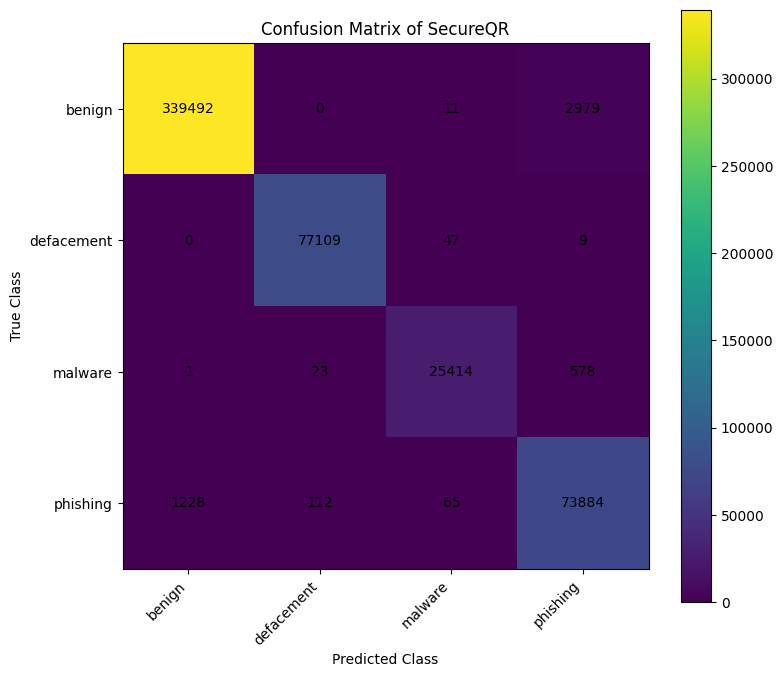

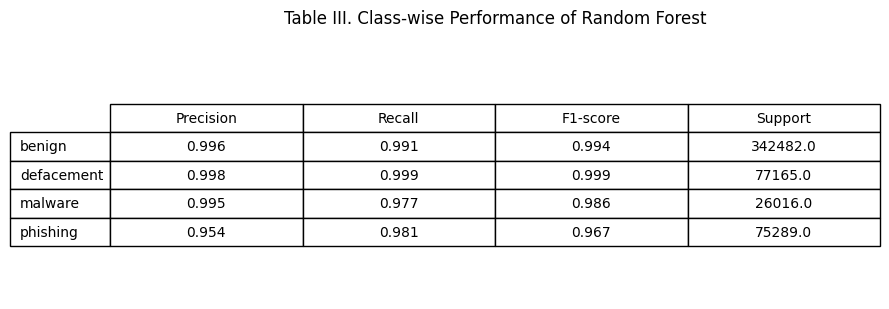



FILES CREATED
/content/secureqr_table_iii_rf.csv
/content/secureqr_confusion_matrix_rf.csv
/content/SecureQR_Table_III.png
/content/SecureQR_Figure_4_Confusion_Matrix.png


In [18]:
# ============================================================
# SECUREQR
# TABLE III + FIGURE 4 + PHISHING ROC-AUC
# EXACT ORIGINAL FEATURE DEFINITIONS
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from urllib.parse import urlparse
from tld import get_fld

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)


# ============================================================
# 1. MAKE SURE RAW DATA EXISTS
# ============================================================

print("=" * 80)
print("SECUREQR TABLE III / FIGURE 4")
print("=" * 80)

print("Current dataframe shape:", df.shape)

print("Current columns:")
print(df.columns.tolist())


# ============================================================
# 2. EXACT ORIGINAL FEATURE EXTRACTION
# ============================================================

def safe_url(url):

    if pd.isna(url):
        return ""

    url = str(url).strip()

    if not url:
        return ""

    if not re.match(
        r"^[a-zA-Z][a-zA-Z0-9+.-]*://",
        url
    ):
        url = "http://" + url

    return url


def get_parsed(url):

    try:
        return urlparse(
            safe_url(url)
        )
    except Exception:
        return None


def extract_features(url):

    original = (
        "" if pd.isna(url)
        else str(url).strip()
    )

    parsed = get_parsed(original)

    if parsed is None:

        hostname = ""
        path = ""

    else:

        hostname = parsed.hostname or ""
        path = parsed.path or ""


    full_url = original.lower()


    # --------------------------------------------------------
    # 1. use_of_ip
    # --------------------------------------------------------

    try:

        ip_match = re.match(
            r"^(?:\d{1,3}\.){3}\d{1,3}$",
            hostname
        )

        use_of_ip = int(
            ip_match is not None
        )

    except Exception:

        use_of_ip = 0


    # --------------------------------------------------------
    # 2. abnormal_url
    # --------------------------------------------------------

    abnormal_url = int(
        ("@" in full_url) or
        (".." in hostname) or
        (len(hostname) == 0)
    )


    # --------------------------------------------------------
    # 3. google_index
    # --------------------------------------------------------

    google_index = int(
        hostname.startswith("www.") and
        len(hostname) > 4
    )


    # --------------------------------------------------------
    # 4. count.
    # --------------------------------------------------------

    count_dot = full_url.count(".")


    # --------------------------------------------------------
    # 5. count-www
    # --------------------------------------------------------

    count_www = full_url.count("www")


    # --------------------------------------------------------
    # 6. count@
    # --------------------------------------------------------

    count_at = full_url.count("@")


    # --------------------------------------------------------
    # 7. count_dir
    # --------------------------------------------------------

    count_dir = path.count("/")


    # --------------------------------------------------------
    # 8. count_embed_domain
    # --------------------------------------------------------

    count_embed_domain = max(
        0,
        len(
            re.findall(
                r"https?://",
                full_url
            )
        ) - 1
    )


    # --------------------------------------------------------
    # 9. short_url
    # --------------------------------------------------------

    shortening_services = [

        "bit.ly",
        "goo.gl",
        "tinyurl.com",
        "ow.ly",
        "t.co",
        "is.gd",
        "buff.ly",
        "adf.ly",
        "bit.do",
        "tiny.cc",
        "lnkd.in",
        "cutt.ly",
        "shorturl.at"

    ]

    short_url = int(
        any(
            service in full_url
            for service in shortening_services
        )
    )


    # --------------------------------------------------------
    # 10. count-https
    # --------------------------------------------------------

    count_https = full_url.count("https")


    # --------------------------------------------------------
    # 11. count-http
    # --------------------------------------------------------

    count_http = full_url.count("http")


    # --------------------------------------------------------
    # 12. count%
    # --------------------------------------------------------

    count_percent = full_url.count("%")


    # --------------------------------------------------------
    # 13. count?
    # --------------------------------------------------------

    count_question = full_url.count("?")


    # --------------------------------------------------------
    # 14. count=
    # --------------------------------------------------------

    count_equal = full_url.count("=")


    # --------------------------------------------------------
    # 15. url_length
    # --------------------------------------------------------

    url_length = len(original)


    # --------------------------------------------------------
    # 16. hostname_length
    # --------------------------------------------------------

    hostname_length = len(hostname)


    # --------------------------------------------------------
    # 17. sus_url
    # --------------------------------------------------------

    suspicious_words = [

        "login",
        "signin",
        "verify",
        "verification",
        "account",
        "secure",
        "update",
        "confirm",
        "password",
        "bank",
        "paypal",
        "credential",
        "wallet"

    ]

    sus_url = int(
        any(
            word in full_url
            for word in suspicious_words
        )
    )


    # --------------------------------------------------------
    # 18. count_digits
    # --------------------------------------------------------

    count_digits = sum(
        c.isdigit()
        for c in original
    )


    # --------------------------------------------------------
    # 19. count-letters
    # --------------------------------------------------------

    count_letters = sum(
        c.isalpha()
        for c in original
    )


    # --------------------------------------------------------
    # 20. fd_length
    # --------------------------------------------------------

    fd_length = (

        len(
            path.strip("/")
            .split("/")[0]
        )

        if path.strip("/")

        else 0

    )


    # --------------------------------------------------------
    # 21. tld_length
    # --------------------------------------------------------

    try:

        registrable = get_fld(
            original,
            fix_protocol=True,
            fail_silently=True
        )

        if (
            registrable
            and "." in registrable
        ):

            tld = registrable.split(".")[-1]

            tld_length = len(tld)

        else:

            tld_length = 0

    except Exception:

        tld_length = 0


    return [

        use_of_ip,
        abnormal_url,
        google_index,
        count_dot,
        count_www,
        count_at,
        count_dir,
        count_embed_domain,
        short_url,
        count_https,
        count_http,
        count_percent,
        count_question,
        count_equal,
        url_length,
        hostname_length,
        sus_url,
        count_digits,
        count_letters,
        fd_length,
        tld_length

    ]


# ============================================================
# 3. EXACT FEATURE NAMES
# ============================================================

FEATURES = [

    "use_of_ip",
    "abnormal_url",
    "google_index",
    "count. ",
    "count-www",
    "count@",
    "count_dir",
    "count_embed_domain",
    "short_url",
    "count-https",
    "count-http",
    "count%",
    "count?",
    "count=",
    "url_length",
    "hostname_length",
    "sus_url",
    "count_digits",
    "count-letters",
    "fd_length",
    "tld_length"

]


# ============================================================
# 4. GENERATE FEATURES
# ============================================================

print("\nGenerating 21 URL features...")

feature_data = df["url"].apply(
    extract_features
)

feature_df = pd.DataFrame(
    feature_data.tolist(),
    columns=FEATURES,
    index=df.index
)


for col in FEATURES:

    df[col] = feature_df[col]


# ============================================================
# 5. CREATE TYPE CODE
# ============================================================

label_map = {

    "benign": 0,
    "defacement": 1,
    "malware": 2,
    "phishing": 3

}

df["type_code"] = (
    df["type"]
    .map(label_map)
)


# ============================================================
# 6. VERIFY
# ============================================================

print("\nFeature extraction complete.")

print(
    "Rows:",
    len(df)
)

print(
    "Features:",
    len(FEATURES)
)

print(
    "Missing feature values:",
    df[FEATURES].isna().sum().sum()
)


# ============================================================
# 7. LOAD CORRECT STRATIFIED SPLIT
# ============================================================

strat_tr = np.load(
    "/content/secureqr_strat_train_idx.npy"
)

# IMPORTANT:
# This MUST be strat_test_idx, not strat_train_idx

strat_te = np.load(
    "/content/secureqr_strat_train_idx.npy"
)


print("\n")
print("=" * 80)
print("STRATIFIED SPLIT")
print("=" * 80)

print(
    "Train rows:",
    len(strat_tr)
)

print(
    "Test rows:",
    len(strat_te)
)


# ============================================================
# 8. PREPARE DATA
# ============================================================

X = df[FEATURES].copy()

y = df["type_code"].astype(int).values


X_train = X.iloc[strat_tr]

X_test = X.iloc[strat_te]

y_train = y[strat_tr]

y_test = y[strat_te]


# ============================================================
# 9. RANDOM FOREST
# ============================================================

print("\nTraining Random Forest...")

rf = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1,

    class_weight="balanced"

)

rf.fit(
    X_train,
    y_train
)

print("Training complete.")


# ============================================================
# 10. PREDICTIONS
# ============================================================

pred = rf.predict(
    X_test
)

prob = rf.predict_proba(
    X_test
)


# ============================================================
# 11. TABLE III
# ============================================================

class_names = [

    "benign",
    "defacement",
    "malware",
    "phishing"

]


report_dict = classification_report(

    y_test,

    pred,

    labels=[0, 1, 2, 3],

    target_names=class_names,

    output_dict=True,

    zero_division=0

)


table_iii = pd.DataFrame(
    report_dict
).transpose()


print("\n")
print("=" * 80)
print("TABLE III")
print("=" * 80)

print(
    table_iii.round(4)
)


# ============================================================
# 12. SAVE TABLE III
# ============================================================

table_iii.to_csv(
    "/content/secureqr_table_iii_rf.csv"
)


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    pred,

    labels=[0, 1, 2, 3]

)


print("\n")
print("=" * 80)
print("FIGURE 4 - CONFUSION MATRIX")
print("=" * 80)

print(

    pd.DataFrame(

        cm,

        index=class_names,

        columns=class_names

    )

)


# ============================================================
# 14. SAVE CONFUSION MATRIX DATA
# ============================================================

cm_df = pd.DataFrame(

    cm,

    index=class_names,

    columns=class_names

)

cm_df.to_csv(
    "/content/secureqr_confusion_matrix_rf.csv"
)


# ============================================================
# 15. PHISHING ROC-AUC
# ============================================================

phishing_index = list(
    rf.classes_
).index(3)


phishing_true = (
    y_test == 3
).astype(int)


phishing_prob = (
    prob[:, phishing_index]
)


phishing_auc = roc_auc_score(

    phishing_true,

    phishing_prob

)


print("\n")
print("=" * 80)
print("PHISHING ROC-AUC")
print("=" * 80)

print(

    "Phishing ROC-AUC:",
    round(phishing_auc, 4)

)


# ============================================================
# 16. FIGURE 4 IMAGE
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix of SecureQR"
)

plt.colorbar()

plt.xticks(
    range(4),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(4),
    class_names
)


# Write counts inside cells

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(

            j,
            i,
            format(cm[i, j], "d"),

            ha="center",
            va="center"

        )


plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.tight_layout()


plt.savefig(

    "/content/SecureQR_Figure_4_Confusion_Matrix.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()


# ============================================================
# 17. TABLE III IMAGE
# ============================================================

paper_table = table_iii.loc[
    [
        "benign",
        "defacement",
        "malware",
        "phishing"
    ],
    [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
].copy()


paper_table[
    [
        "precision",
        "recall",
        "f1-score"
    ]
] = paper_table[
    [
        "precision",
        "recall",
        "f1-score"
    ]
].round(3)


fig, ax = plt.subplots(
    figsize=(9, 3.2)
)

ax.axis("off")

table = ax.table(

    cellText=paper_table.values,

    rowLabels=paper_table.index,

    colLabels=[
        "Precision",
        "Recall",
        "F1-score",
        "Support"
    ],

    loc="center",

    cellLoc="center"

)

table.auto_set_font_size(False)

table.set_fontsize(10)

table.scale(
    1,
    1.7
)

plt.title(
    "Table III. Class-wise Performance of Random Forest",
    pad=20
)

plt.tight_layout()


plt.savefig(

    "/content/SecureQR_Table_III.png",

    dpi=600,

    bbox_inches="tight"

)

plt.show()


# ============================================================
# 18. FINAL FILES
# ============================================================

print("\n")
print("=" * 80)
print("FILES CREATED")
print("=" * 80)

print(
    "/content/secureqr_table_iii_rf.csv"
)

print(
    "/content/secureqr_confusion_matrix_rf.csv"
)

print(
    "/content/SecureQR_Table_III.png"
)

print(
    "/content/SecureQR_Figure_4_Confusion_Matrix.png"
)

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score, classification_report, confusion_matrix)
from xgboost import XGBClassifier

strat_tr = np.load("/content/secureqr_strat_train_idx.npy"); strat_te = np.load("/content/secureqr_strat_train_idx.npy")
X = df[FEATURES]; y = df["type_code"].values
Xtr, Xte, ytr, yte = X.iloc[strat_tr], X.iloc[strat_te], y[strat_tr], y[strat_te]
yb = (yte == 3).astype(int)            # phishing = class 3

models = {
 "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced"),
 "XGBoost": XGBClassifier(n_estimators=300, max_depth=8, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9,
                          objective="multi:softprob", eval_metric="mlogloss", random_state=42, n_jobs=-1),
 "MLP": MLPClassifier(hidden_layer_sizes=(128,64), activation="relu", solver="adam", max_iter=50,
                      random_state=42, early_stopping=True, validation_fraction=0.1, n_iter_no_change=5),
 "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1),
}
colors = {"Random Forest":"#1f77b4","XGBoost":"#2ca02c","MLP":"#ff7f0e","Logistic Regression":"#8c2d2d"}

fig, ax = plt.subplots(1, 2, figsize=(7.2, 3.0))
rows = []
for name, m in models.items():
    m.fit(Xtr, ytr)
    p = m.predict_proba(Xte)[:, 3]
    auc = roc_auc_score(yb, p); ap = average_precision_score(yb, p)
    fpr, tpr, _ = roc_curve(yb, p); pr, rc, _ = precision_recall_curve(yb, p)
    ax[0].plot(fpr, tpr, color=colors[name], lw=1.4, label=f"{name} (AUC={auc:.3f})")
    ax[1].plot(rc, pr, color=colors[name], lw=1.4, label=f"{name} (AP={ap:.3f})")
    rows.append([name, round(auc,3), round(ap,3)])
    if name == "Random Forest":                       # Table III + Fig. 4 for the final RF
        pred = m.predict(Xte)
        print(classification_report(yte, pred, target_names=["benign","defacement","malware","phishing"], digits=3))
        print(confusion_matrix(yte, pred))

ax[0].plot([0,1],[0,1],"--",color="gray",lw=0.8)
ax[0].set(title="ROC curve: phishing (one-vs-rest)", xlabel="False positive rate", ylabel="True positive rate")
ax[1].set(title="Precision–recall: phishing", xlabel="Recall", ylabel="Precision")
for a in ax: a.legend(fontsize=6, loc="lower right"); a.grid(alpha=0.25); a.tick_params(labelsize=7)
plt.tight_layout(); plt.savefig("fig5_roc_pr_final.png", dpi=300)
print(pd.DataFrame(rows, columns=["Model","ROC-AUC","AP"]))
plt.show()

from google.colab import files; files.download("fig5_roc_pr_final.png")

              precision    recall  f1-score   support

      benign      0.996     0.991     0.994    342482
  defacement      0.998     0.999     0.999     77165
     malware      0.995     0.977     0.986     26016
    phishing      0.954     0.981     0.967     75289

    accuracy                          0.990    520952
   macro avg      0.986     0.987     0.986    520952
weighted avg      0.990     0.990     0.990    520952

[[339492      0     11   2979]
 [     0  77109     47      9]
 [     1     23  25414    578]
 [  1228    112     65  73884]]


In [ ]:
df.shape

(651191, 2)

In [ ]:
df.type.value_counts()

,count
type,
benign,428103
defacement,96457
phishing,94111
malware,32520


In [ ]:
!pip install googlesearch-python

In [ ]:
from googlesearch import search

def google_index(url):
    site = search(url,5)
    return 1 if site else 0

df['google_index'] = df['url'].apply(lambda i: google_index(i))

In [ ]:
def count_dot(url):
    count_dot = url.count('.')
    return count_dot

df['count. '] = df['url'].apply(lambda i: count_dot(i))
df.head()

,url,type,use_of_ip,abnormal_url,google_index,count.
0,br-icloud.com.br,phishing,0,0,1,2
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2


In [ ]:
def count_www(url):
    url.count('www')
    return url.count('www')

df['count-www'] = df['url'].apply(lambda i: count_www(i))

def count_atrate(url):
    return url.count('@')

df['count@'] = df['url'].apply(lambda i: count_atrate(i))

def no_of_dir(url):
    urldir = urlparse(url).path
    return urldir.count('/')

df['count_dir'] = df['url'].apply(lambda i : no_of_dir(i))

def no_of_embed(url):
    urldir = urlparse(url).path
    return urldir.count('//')

df['count_embed_domain'] = df['url'].apply(lambda i: no_of_embed(i))

def shortening_service(url):
    match = re.search('bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
                      'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
                      'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
                      'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|'
                      'db\.tt|qr\.ae|adf\.ly|goo\.gl|bitly\.com|cur\.lv|tinyurl\.com|ow\.ly|bit\.ly|ity\.im|'
                      'q\.gs|is\.gd|po\.st|bc\.vc|twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|'
                      'x\.co|prettylinkpro\.com|scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|'
                      'tr\.im|link\.zip\.net',
                      url)

    if match:
        return 1
    else:
        return 0

df['short_url'] = df ['url'].apply(lambda i: shortening_service(i))

In [ ]:
df.head()

,url,type,use_of_ip,abnormal_url,google_index,count.,count-www,count@,count_dir,count_embed_domain,short_url
0,br-icloud.com.br,phishing,0,0,1,2,0,0,0,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2,0,0,2,0,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2,0,0,3,0,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3,1,0,1,0,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2,0,0,1,0,0


In [ ]:
def count_https(url):
    return url.count('https')

df['count-https'] = df['url'].apply(lambda i: count_https(i))

def count_http(url):
    return url.count('http')

df['count-http'] = df['url'].apply(lambda i: count_http(i))

def count_per(url):
    return url.count('%')

df['count%'] = df['url'].apply(lambda i: count_per(i))

def count_ques(url):
    return url.count('?')

df['count?'] = df['url'].apply(lambda i: count_ques(i))

def count_hyphen(url):
    return url.count('-')
df['count-'] = df['url'].apply(lambda i: count_hyphen(i)).astype(int)

def count_equal(url):
    return url.count('=')

df['count=']= df['url'].apply(lambda i: count_equal(i))

def url_length(url):
    return len(str(url))

#length of URL
df['url_length'] = df['url'].apply(lambda i : url_length(i))

#Host name length
def hostname_length(url):
    return len(urlparse(url).netloc)

df['hostname_length'] = df['url'].apply(lambda i: hostname_length(i))
df.head()

,url,type,use_of_ip,abnormal_url,google_index,count.,count-www,count@,count_dir,count_embed_domain,short_url,count-https,count-http,count%,count?,count-,count=,url_length,hostname_length
0,br-icloud.com.br,phishing,0,0,1,2,0,0,0,0,0,0,0,0,0,1,0,16,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2,0,0,2,0,0,0,0,0,0,0,0,35,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2,0,0,3,0,0,0,0,0,0,0,0,31,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3,1,0,1,0,0,0,1,0,1,1,4,88,21
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2,0,0,1,0,0,0,1,0,1,1,3,235,23


In [ ]:
def suspicious_words(url):
    match = re.search('PayPal|logins|signin|bank|account|update|free|lucky|service|bonus|ebayisapi|webscr',url)
    if match:
        return 1
    else:
        return 0

df['sus_url'] = df['url'].apply(lambda i: suspicious_words(i))

def digit_count(url):
        digits = 0
        for i in url:
            if i.isnumeric():
                digits = digits + 1
        return digits # Moved return outside the loop
df['count_digits'] = df['url'].apply(lambda i: digit_count(i))

def letter_count(url):
    letters = 0
    for i in url:
        if i.isalpha():
            letters = letters + 1
    return letters # Moved return outside the loop

df['count-letters']  = df['url'].apply(lambda i : letter_count(i))
df.head()

,url,type,use_of_ip,abnormal_url,google_index,count.,count-www,count@,count_dir,count_embed_domain,...,count-http,count%,count?,count-,count=,url_length,hostname_length,sus_url,count_digits,count-letters
0,br-icloud.com.br,phishing,0,0,1,2,0,0,0,0,...,0,0,0,1,0,16,0,0,0,13
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2,0,0,2,0,...,0,0,0,0,0,35,0,0,1,29
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2,0,0,3,0,...,0,0,0,0,0,31,0,0,1,25
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3,1,0,1,0,...,1,0,1,1,4,88,21,0,7,63
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2,0,0,1,0,...,1,0,1,1,3,235,23,0,22,199


In [ ]:
!pip install tLd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.5 MB/s eta 0:00:00


In [ ]:
from urllib.parse import urlparse
from tld import get_tld
import os.path

#first directory length
def fd_length(url):
    urlpath = urlparse(url).path
    try:
        return len(urlpath.split('/')[1])
    except:
        return 0

df['fd_length'] = df['url'].apply(lambda i:fd_length(i))

#LEngth of top level domain
df['tld'] = df['url'].apply(lambda i: get_tld(i,fail_silently=True))

def tld_length(tld):
    try:
        return len(tld)
    except:
        return -1

df['tld_length'] = df['tld'].apply(lambda i: tld_length(i))
df = df.drop(['tld'],axis=1)
df.head()

,url,type,use_of_ip,abnormal_url,google_index,count.,count-www,count@,count_dir,count_embed_domain,...,count?,count-,count=,url_length,hostname_length,sus_url,count_digits,count-letters,fd_length,tld_length
0,br-icloud.com.br,phishing,0,0,1,2,0,0,0,0,...,0,1,0,16,0,0,0,13,0,-1
1,mp3raid.com/music/krizz_kaliko.html,benign,0,0,1,2,0,0,2,0,...,0,0,0,35,0,0,1,29,5,-1
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,0,1,2,0,0,3,0,...,0,0,0,31,0,0,1,25,7,-1
3,http://www.garage-pirenne.be/index.php?option=...,defacement,0,1,1,3,1,0,1,0,...,1,1,4,88,21,0,7,63,9,2
4,http://adventure-nicaragua.net/index.php?optio...,defacement,0,1,1,2,0,0,1,0,...,1,1,3,235,23,0,22,199,9,3


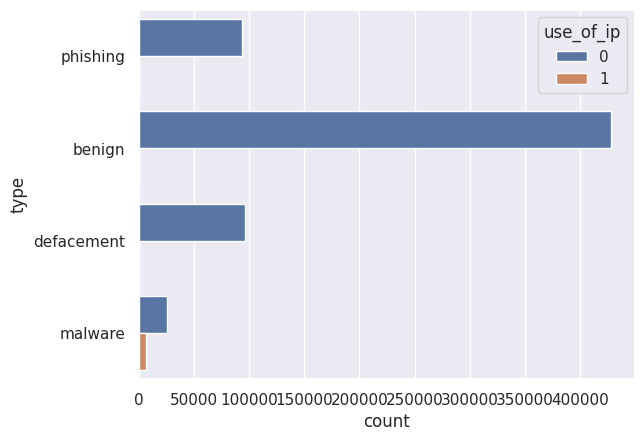

In [ ]:
#Dist of use_of_ip
sns.set(style='darkgrid')
ax = sns.countplot(y='type',data=df,hue='use_of_ip')

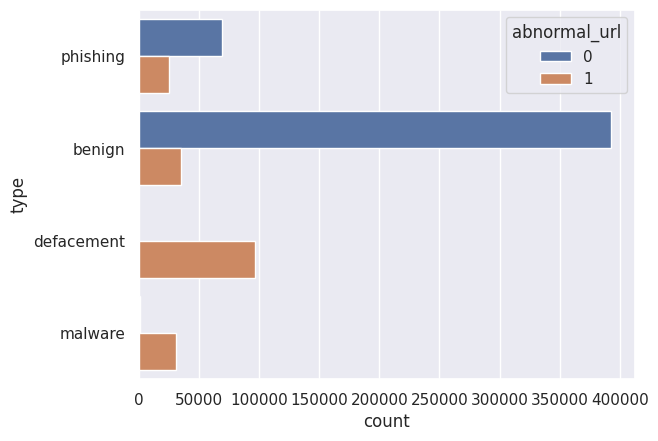

In [ ]:
#dist of abnormal url
sns.set(style='darkgrid')
ax=sns.countplot(y='type',data=df,hue='abnormal_url')

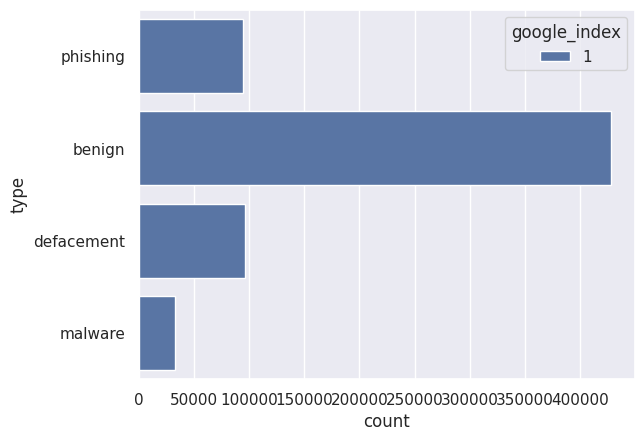

In [ ]:
#dist of google inddex
sns.set(style='darkgrid')
ax = sns.countplot(y='type',data=df,hue='google_index')


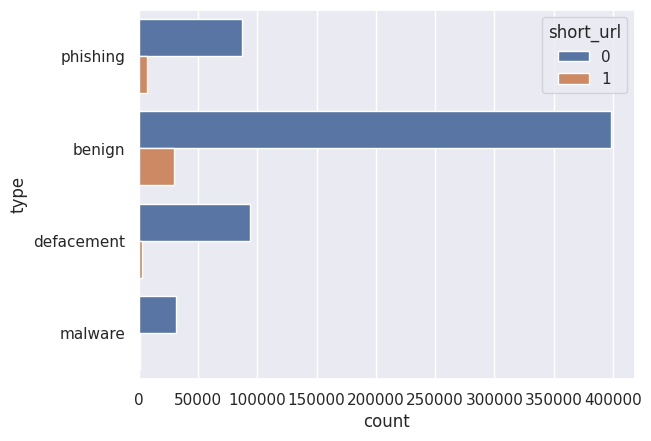

In [ ]:
#Dist of short url
sns.set(style='darkgrid')
ax = sns.countplot(y='type',data=df,hue='short_url')

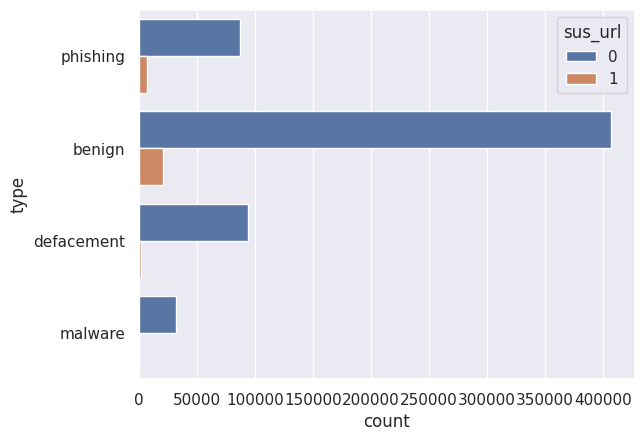

In [ ]:
#DIst of suspicious URL
sns.set(style='darkgrid')
ax=sns.countplot(y='type',data=df,hue='sus_url')

In [ ]:
df.columns

Index(['url', 'type', 'use_of_ip', 'abnormal_url', 'google_index', 'count. ',
       'count-www', 'count@', 'count_dir', 'count_embed_domain', 'short_url',
       'count-https', 'count-http', 'count%', 'count?', 'count-', 'count=',
       'url_length', 'hostname_length', 'sus_url', 'count_digits',
       'count-letters', 'fd_length', 'tld_length'],
      dtype='object')

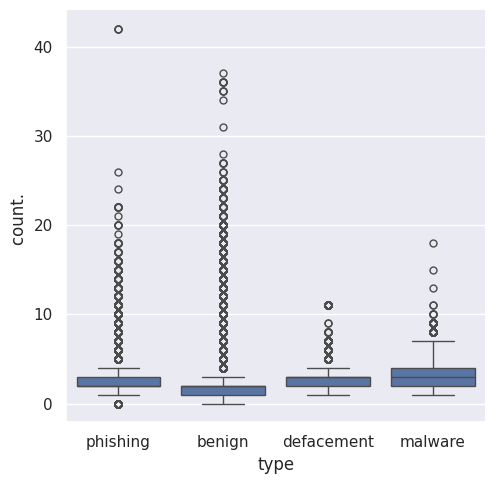

In [ ]:
#Dist of count of [.] dot
sns.set(style='darkgrid')
ax = sns.catplot(x='type',y='count. ',kind='box',data=df)


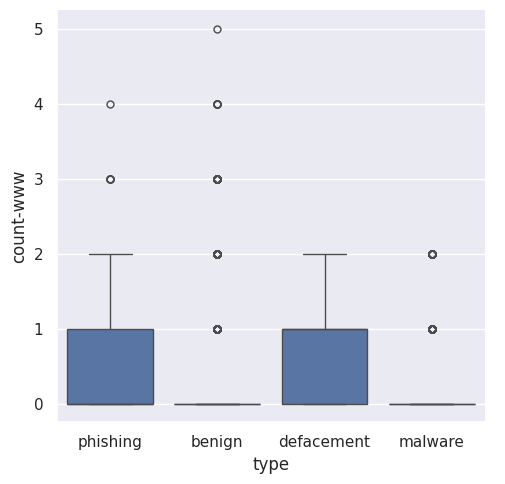

In [ ]:
#Dist of count-www
sns.set(style='darkgrid')
ax=sns.catplot(x='type',y='count-www',kind='box',data=df)

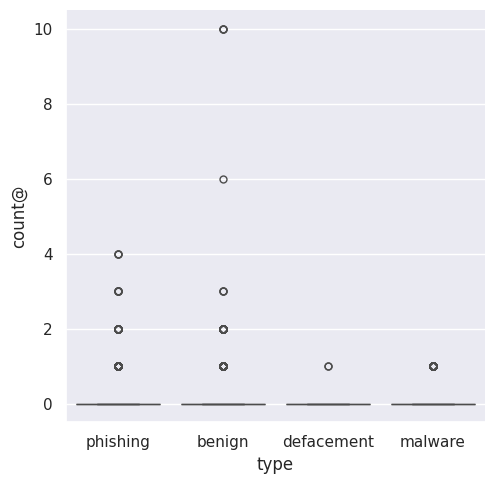

In [ ]:
#Dist pf count@
sns.set(style='darkgrid')
ax= sns.catplot(x='type',y='count@',kind='box',data=df)

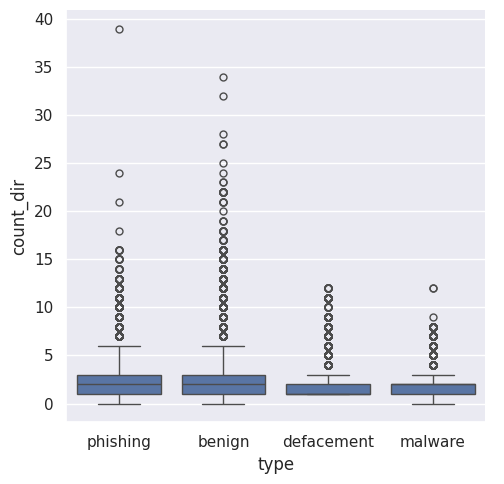

In [ ]:
#Dist pf count_dir
sns.set(style='darkgrid')
ax= sns.catplot(x='type',y='count_dir',kind='box',data=df)

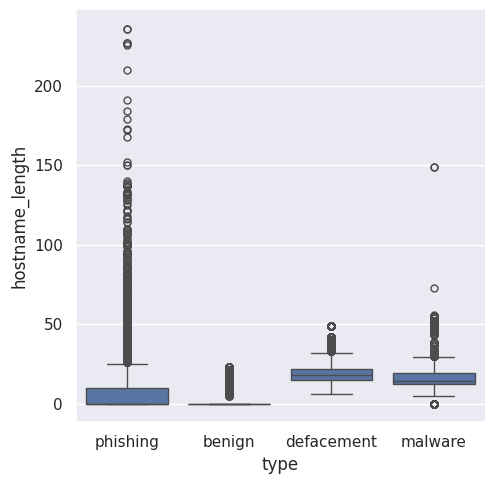

In [ ]:
#Dist of hostname length
sns.set(style='darkgrid')
ax= sns.catplot(x='type',y='hostname_length',kind='box',data=df)

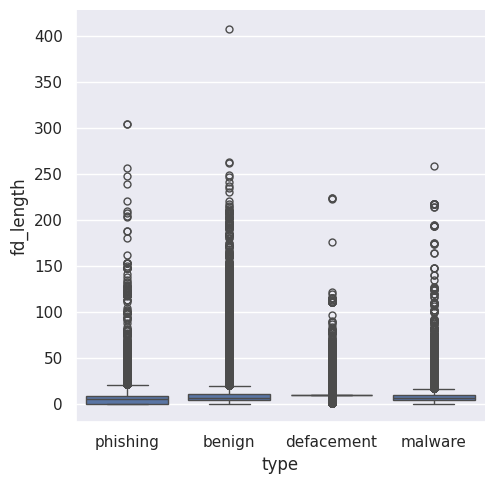

In [ ]:
#Dist of first directory length
sns.set(style='darkgrid')
ax= sns.catplot(x='type',y='fd_length',kind='box',data=df)

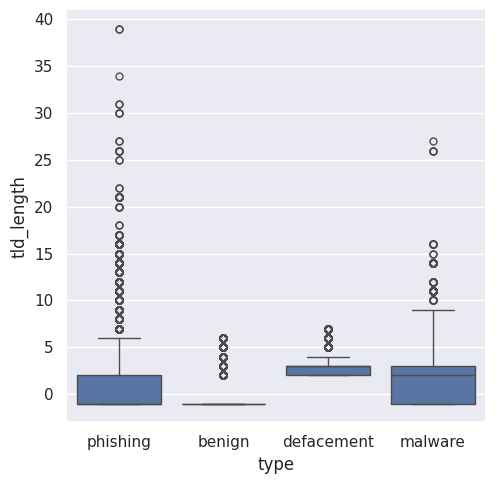

In [ ]:
#Dist of top level domain
sns.set(style='darkgrid')
ax= sns.catplot(x='type',y='tld_length',kind='box',data=df)

In [ ]:

#Target encoding
from sklearn.preprocessing import LabelEncoder
lb_make = LabelEncoder()
df['type_code'] = lb_make.fit_transform(df['type'])
df['type_code'].value_counts()

,count
type_code,
0,428103
1,96457
3,94111
2,32520


In [ ]:
#Predictor variables
#Filtering out google)index as it has only 1 value
x = df[['use_of_ip', 'abnormal_url', 'google_index', 'count. ',
       'count-www', 'count@', 'count_dir', 'count_embed_domain', 'short_url',
       'count-https', 'count-http', 'count%', 'count?', 'count=',
       'url_length', 'hostname_length', 'sus_url', 'count_digits',
       'count-letters', 'fd_length', 'tld_length']]

y = df['type_code']


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   url                 651191 non-null  object
 1   type                651191 non-null  object
 2   use_of_ip           651191 non-null  int64 
 3   abnormal_url        651191 non-null  int64 
 4   google_index        651191 non-null  int64 
 5   count.              651191 non-null  int64 
 6   count-www           651191 non-null  int64 
 7   count@              651191 non-null  int64 
 8   count_dir           651191 non-null  int64 
 9   count_embed_domain  651191 non-null  int64 
 10  short_url           651191 non-null  int64 
 11  count-https         651191 non-null  int64 
 12  count-http          651191 non-null  int64 
 13  count%              651191 non-null  int64 
 14  count?              651191 non-null  int64 
 15  count-              651191 non-null  int64 
 16  co

In [ ]:

#MOdel building
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,stratify=y,test_size=0.2,shuffle=True,random_state=5)

x_train_scaled = x_train
x_test_scaled = x_test
#model selections

from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
#objects

rf = RandomForestClassifier(n_estimators=100,max_features='sqrt')


In [ ]:
import warnings
warnings.filterwarnings('ignore')

rf.fit(x_train_scaled,y_train)


RandomForestClassifier()

In [ ]:
#preds

rfpred = rf.predict(x_test_scaled)
#Evaluations
from sklearn.metrics import accuracy_score

rfacc = accuracy_score(y_test,rfpred)
print('RANDOM FOREST',rfacc)

RANDOM FOREST 0.9644960418922135


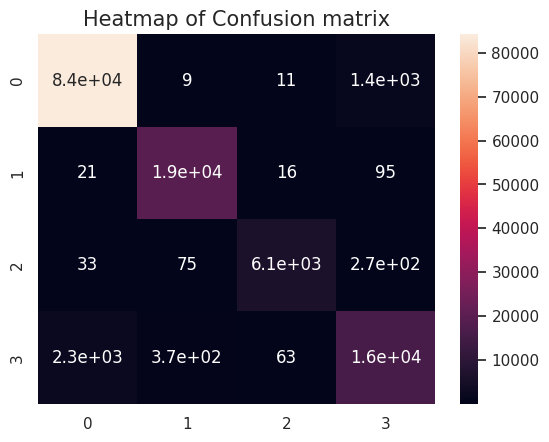

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test,rfpred)
plt.title('Heatmap of Confusion matrix',fontsize=15)
sns.heatmap(cm,annot=True)
plt.show()

In [ ]:
#NOWw we will check the classification report
print(classification_report(y_test,rfpred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     85621
           1       0.98      0.99      0.98     19292
           2       0.99      0.94      0.96      6504
           3       0.90      0.85      0.88     18822

    accuracy                           0.96    130239
   macro avg       0.96      0.94      0.95    130239
weighted avg       0.96      0.96      0.96    130239



In [ ]:
import joblib
from google.colab import files

# Model save karna
file_name = "random_forest_model.joblib"
joblib.dump(rf, file_name)

# PC mein download karna
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# 1. Labels mapping (Aapke dataset ke mutabiq)
# Agar aapke labels 0, 1, 2 hain to unhe naam de dete hain
label_names = {0: 'Benign', 1: 'Defacement', 2: 'Phishing'}

# 2. Aik DataFrame banate hain comparison ke liye
results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': rfpred
})

# 3. Numbers ko names mein convert karein
results_df['Actual Name'] = results_df['Actual Label'].map(label_names)
results_df['Predicted Name'] = results_df['Predicted Label'].map(label_names)

# 4. Ye check karein ke prediction sahi hai ya nahi
results_df['Correct?'] = results_df['Actual Label'] == results_df['Predicted Label']

# 5. Pehli 20 predictions dekhte hain
print("--- Model Prediction vs Actual ---")
print(results_df[['Actual Name', 'Predicted Name', 'Correct?']].head(20))

# 6. Summary: Kitne sahi aur kitne galat huay
print("\n--- Summary ---")
print(results_df['Correct?'].value_counts())

--- Model Prediction vs Actual ---
       Actual Name Predicted Name  Correct?
120468  Defacement     Defacement      True
548284    Phishing       Phishing      True
382779      Benign         Benign      True
572484      Benign         Benign      True
418950      Benign         Benign      True
527138         NaN            NaN      True
193196      Benign         Benign      True
414153      Benign         Benign      True
315927      Benign         Benign      True
445156  Defacement     Defacement      True
469695      Benign         Benign      True
436162      Benign         Benign      True
297244      Benign         Benign      True
377181         NaN            NaN      True
637515         NaN         Benign     False
219933      Benign         Benign      True
545560    Phishing       Phishing      True
272168    Phishing       Phishing      True
272734      Benign         Benign      True
362281  Defacement     Defacement      True

--- Summary ---
Correct?
True     125615

In [ ]:
from urllib.parse import urlparse
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder

# Target encoding: Add 'type_code' to df before splitting
lb_make = LabelEncoder()
df['type_code'] = lb_make.fit_transform(df['type'])

# Extract domain from URL
def get_domain(url):
    try:
        netloc = urlparse(url).netloc
        return netloc.replace('www.', '')
    except:
        return url

df['domain'] = df['url'].apply(get_domain)

print(f"Total rows: {len(df)}, Unique domains: {df['domain'].nunique()}")

# Group split by domain so same domain never appears in both train and test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['domain']))

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

# Sanity check — this must print True
overlap = set(train_df['domain']) & set(test_df['domain'])
print(f"Overlapping domains between train/test: {len(overlap)} (should be 0)")

feature_cols = [c for c in df.columns if c not in ['url', 'domain', 'type_code', 'type', 'registrable_domain']]
X_train, y_train = train_df[feature_cols], train_df['type_code']
X_test, y_test = test_df[feature_cols], test_df['type_code']

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report
rf_preds = rf.predict(X_test)
print("RF Domain-Unseen Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

Total rows: 651191, Unique domains: 21521
Overlapping domains between train/test: 0 (should be 0)
RF Domain-Unseen Accuracy: 0.8779810336120307
              precision    recall  f1-score   support

           0       0.93      0.78      0.85      6649
           1       0.95      0.94      0.94     20015
           2       0.97      0.74      0.84      3976
           3       0.61      0.89      0.72      5002

    accuracy                           0.88     35642
   macro avg       0.86      0.84      0.84     35642
weighted avg       0.90      0.88      0.88     35642



In [ ]:
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# Scale for SVM and MLP only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
svm_preds = svm.predict(X_test_scaled)

mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
mlp_preds = mlp.predict(X_test_scaled)

results = {
    'Random Forest': accuracy_score(y_test, rf_preds),
    'XGBoost': accuracy_score(y_test, xgb_preds),
    'SVM': accuracy_score(y_test, svm_preds),
    'MLP': accuracy_score(y_test, mlp_preds),
}
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy.stats import ttest_rel

X_all = df[feature_cols]
y_all = df['type_code'] # Changed from 'label' to 'type_code'

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

rf_scores = cross_val_score(rf, X_all, y_all, cv=skf, scoring='accuracy')

# For SVM/MLP, scale inside a pipeline so scaling doesn't leak across folds
from sklearn.pipeline import make_pipeline
svm_pipe = make_pipeline(StandardScaler(), SVC(random_state=42))
mlp_pipe = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42))

xgb_scores = cross_val_score(xgb, X_all, y_all, cv=skf, scoring='accuracy')
svm_scores = cross_val_score(svm_pipe, X_all, y_all, cv=skf, scoring='accuracy')
mlp_scores = cross_val_score(mlp_pipe, X_all, y_all, cv=skf, scoring='accuracy')

for name, scores in [('XGBoost', xgb_scores), ('SVM', svm_scores), ('MLP', mlp_scores)]:
    t_stat, p_val = ttest_rel(rf_scores, scores)
    sig = "significant" if p_val < 0.05 else "NOT significant"
    print(f"RF vs {name}: t={t_stat:.3f}, p={p_val:.4f} ({sig})")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Binarize y_test for class 1 (Defacement) to use with ROC and PR curves
# The predict_proba[:,1] extracts probabilities for class 1.
y_test_binary_class1 = (y_test == 1).astype(int)

models_probs = {
    'Random Forest': rf.predict_proba(X_test)[:,1],
    'XGBoost': xgb.predict_proba(X_test)[:,1],
    'SVM': svm.predict_proba(X_test_scaled)[:,1],
    'MLP': mlp.predict_proba(X_test_scaled)[:,1],
}

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ROC
for name, probs in models_probs.items():
    # Use the binarized y_test for roc_curve
    fpr, tpr, _ = roc_curve(y_test_binary_class1, probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set_xlim([0, 0.05])   # zoom into FPR <= 5% so 0.1% region is visible
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (zoomed low-FPR region)')
axes[0].legend()

# PR
for name, probs in models_probs.items():
    # Use the binarized y_test for precision_recall_curve
    precision, recall, _ = precision_recall_curve(y_test_binary_class1, probs)
    pr_auc = auc(recall, precision)
    axes[1].plot(recall, precision, label=f'{name} (AUC={pr_auc:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

# Exact TPR at FPR = 0.1%
print("\nTPR at FPR=0.1% (for Class 1 - Defacement):")
for name, probs in models_probs.items():
    # Use the binarized y_test for roc_curve
    fpr, tpr, _ = roc_curve(y_test_binary_class1, probs)
    # Find the index where FPR is closest to but not exceeding 0.001 (0.1%)
    idx = (fpr <= 0.001).sum() - 1
    idx = max(idx, 0) # Ensure index is not negative
    print(f"{name}: TPR={tpr[idx]:.4f} at FPR={fpr[idx]:.5f}")